In [ ]:
# =====================================================
# 1. Iniciar Google Drive
# =====================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers scikit-learn pandas tqdm

In [ ]:
# =====================================================
# 2. Importar librerias y buscar GPU
# =====================================================
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import os
import zipfile

from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    confusion_matrix
)
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt




print("Torch version:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA version en PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("GPU no disponible, usando CPU")
    device = torch.device("cpu")

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Torch version: 2.11.0+cu128
CUDA disponible: True
CUDA version en PyTorch: 12.8
GPU: Tesla T4


In [ ]:
# =====================================================
# 3. Declarar rutas para guardar datos
# =====================================================
project_path = "/content/drive/MyDrive/DAACC/Reto/Equipo 1/Reto Plagio"

zip_path = os.path.join(project_path, "SOCO.zip")
extract_path = "/content"

model_name = "neulab/codebert-cpp"

batch_size = 16
max_length = 256
chunk_size = 5000

output_embeddings_path = os.path.join(
    project_path,
    "Samir/codebert_cpp_train_embeddings.pt"
)

output_mlp_path = os.path.join(
    project_path,
    "Samir/mlp_plagiarism_detector_codebert_cpp.pt"
)

In [ ]:
# =====================================================
# 4. Descomprimir ZIP de dataset
# =====================================================
start = time.time()

if not os.path.exists("/content/SOCO"):
    print("Descomprimiendo SOCO.zip...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("Descompresión terminada.")
else:
    print("SOCO ya existe en /content.")

end = time.time()

print(f"Tiempo: {(end - start) / 60:.2f} minutos")

Descomprimiendo SOCO.zip...
Descompresión terminada.
Tiempo: 0.57 minutos


In [ ]:
# =====================================================
# 5. Declarar rutas de códigos y metadata
# =====================================================
local_soco_path = "/content/SOCO"

if not os.path.exists(os.path.join(local_soco_path, "train.csv")):
    possible_nested_path = os.path.join(local_soco_path, "SOCO")

    if os.path.exists(os.path.join(possible_nested_path, "train.csv")):
        local_soco_path = possible_nested_path
    else:
        raise FileNotFoundError(
            "No se encontró train.csv en /content/SOCO ni en /content/SOCO/SOCO. "
            "Revisa cómo se descomprimió el zip."
        )

train_csv_path = os.path.join(local_soco_path, "train.csv")
dev_csv_path = os.path.join(local_soco_path, "dev.csv")
test_csv_path = os.path.join(local_soco_path, "test.csv")

train_folder = os.path.join(local_soco_path, "train")
dev_folder = os.path.join(local_soco_path, "dev")
test_folder = os.path.join(local_soco_path, "test")

print("Ruta SOCO local:", local_soco_path)
print("Train CSV:", train_csv_path)
print("Train folder:", train_folder)

print("\nContenido de SOCO:")
print(os.listdir(local_soco_path)[:20])

Ruta SOCO local: /content/SOCO
Train CSV: /content/SOCO/train.csv
Train folder: /content/SOCO/train

Contenido de SOCO:
['dev', 'unlabeled_test.csv', 'test', 'dev.csv', 'train.csv', 'train']


In [ ]:
# =====================================================
# 6. Cargar solo metadata del CSV, NO los códigos completos
# =====================================================

train_df = pd.read_csv(train_csv_path)

required_columns = {"pid", "uid"}

if not required_columns.issubset(set(train_df.columns)):
    raise ValueError(
        f"El CSV debe contener las columnas {required_columns}. "
        f"Columnas encontradas: {set(train_df.columns)}"
    )

train_df["pid"] = train_df["pid"].astype(str)

print("Total de registros en train.csv:", len(train_df))
print(train_df.head())

Total de registros en train.csv: 50000
   uid    pid
0  415  27909
1  415  55938
2  415  90936
3  415  56858
4  415   9447


In [ ]:
# =====================================================
# 7. Cargar tokenizer y modelo CodeBERT C++
# =====================================================

tokenizer = AutoTokenizer.from_pretrained(model_name)
codebert_model = AutoModel.from_pretrained(model_name)

codebert_model.to(device)
codebert_model.eval()

print("Modelo cargado:", model_name)
print("Device:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: neulab/codebert-cpp
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo cargado: neulab/codebert-cpp
Device: cuda


In [ ]:
# =====================================================
# 8. Generación de embeddings con checkpoints por chunks
# =====================================================

import gc
import os
import torch
import torch.nn.functional as F
from tqdm import tqdm

chunk_dir = os.path.join(project_path, "embedding_chunks_codebert_cpp")
os.makedirs(chunk_dir, exist_ok=True)


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()

    summed = torch.sum(
        last_hidden_state * mask,
        dim=1
    )

    counts = torch.clamp(
        mask.sum(dim=1),
        min=1e-9
    )

    return summed / counts

In [ ]:
def procesar_batch_codigos(
    batch_codigos,
    tokenizer,
    model,
    device,
    max_length
):
    '''
    Genera embeddings para un batch de códigos fuente

    Parámetros:
    ----------
    batch_codigos : list[str]
        Lista de códigos fuente a procesar.

    tokenizer : TransformerTokenizer
        Tokenizador asociado al modelo.

    model : TransformerModel
        Modelo encargado de generar las representaciones vectoriales.

    device : torch.device
        Dispositivo de ejecución (CPU o GPU).

    max_length : int
        Longitud máxima de tokens permitida por secuencia.

    Return:
    --------
    torch.Tensor
        Tensor de embeddings normalizados con tamaño
        (batch_size, embedding_dimension).
    '''
    tokens = tokenizer(
        batch_codigos,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = tokens["input_ids"].to(device)
    attention_mask = tokens["attention_mask"].to(device)

    with torch.inference_mode():
        if device.type == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
        else:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        batch_embeddings = mean_pooling(
            outputs.last_hidden_state,
            attention_mask
        )

        batch_embeddings = F.normalize(
            batch_embeddings,
            p=2,
            dim=1
        )

    return batch_embeddings.cpu().half()

In [ ]:
def generar_embeddings_con_checkpoints(
    df,
    folder_path,
    tokenizer,
    model,
    device,
    batch_size=16,
    max_length=256,
    chunk_size=5000,
    chunk_dir=chunk_dir
):
    '''
      Genera embeddings para archivos de código fuente.

      Para evitar perder progreso y reducir el consumo de memoria, los resultados
        se procesan y almacenan en chunks independientes.

        Parámetros:
        ----------
        df : DataFrame (uid, pid)

        folder_path : str

        tokenizer : TransformerTokenizer

        model : TransformerModel
            Modelo encargado de generar los embeddings.

        device : torch.device (GPU)

        batch_size : int

        max_length : int

        chunk_size : int
            Cantidad de registros procesados antes de guardar un checkpoint.

        chunk_dir : str
            Directorio donde se almacenarán los chunks generados.
    '''
    total_registros = len(df)

    print("Total de registros:", total_registros)
    print("Batch size:", batch_size)
    print("Max length:", max_length)
    print("Chunk size:", chunk_size)
    print("Guardando chunks en:", chunk_dir)

    for chunk_start in range(0, total_registros, chunk_size):

        chunk_end = min(chunk_start + chunk_size, total_registros)

        chunk_path = os.path.join(
            chunk_dir,
            f"chunk_{chunk_start:05d}_{chunk_end:05d}.pt"
        )

        if os.path.exists(chunk_path):
            print(f"Chunk ya existe, se omite: {chunk_path}")
            continue

        print(f"\nProcesando chunk {chunk_start} - {chunk_end}")

        chunk_df = df.iloc[chunk_start:chunk_end]

        chunk_embeddings = []
        chunk_labels = []
        chunk_file_ids = []
        chunk_errores = []

        batch_codigos = []
        batch_labels = []
        batch_file_ids = []

        for _, row in tqdm(
            chunk_df.iterrows(),
            total=len(chunk_df),
            desc=f"Chunk {chunk_start}-{chunk_end}"
        ):

            nombre_archivo = str(row["pid"])
            ruta_archivo = os.path.join(folder_path, nombre_archivo)

            try:
                with open(ruta_archivo, "r", encoding="utf-8", errors="ignore") as f:
                    codigo = f.read()

                codigo = codigo.replace("\t", " ").strip()

                if len(codigo) == 0:
                    chunk_errores.append((nombre_archivo, "archivo vacío"))
                    continue

                batch_codigos.append(codigo)
                batch_labels.append(row["uid"])
                batch_file_ids.append(nombre_archivo)

            except Exception as e:
                chunk_errores.append((nombre_archivo, str(e)))
                continue

            if len(batch_codigos) == batch_size:

                batch_embeddings = procesar_batch_codigos(
                    batch_codigos=batch_codigos,
                    tokenizer=tokenizer,
                    model=model,
                    device=device,
                    max_length=max_length
                )

                chunk_embeddings.append(batch_embeddings)
                chunk_labels.extend(batch_labels)
                chunk_file_ids.extend(batch_file_ids)

                batch_codigos = []
                batch_labels = []
                batch_file_ids = []

                del batch_embeddings
                gc.collect()

                if device.type == "cuda":
                    torch.cuda.empty_cache()

        # Procesar sobrantes del batch
        if len(batch_codigos) > 0:

            batch_embeddings = procesar_batch_codigos(
                batch_codigos=batch_codigos,
                tokenizer=tokenizer,
                model=model,
                device=device,
                max_length=max_length
            )

            chunk_embeddings.append(batch_embeddings)
            chunk_labels.extend(batch_labels)
            chunk_file_ids.extend(batch_file_ids)

            del batch_embeddings
            gc.collect()

            if device.type == "cuda":
                torch.cuda.empty_cache()

        if len(chunk_embeddings) > 0:
            chunk_embeddings = torch.cat(chunk_embeddings, dim=0)
        else:
            chunk_embeddings = torch.empty((0, 768), dtype=torch.float16)

        torch.save(
            {
                "embeddings": chunk_embeddings,
                "labels": chunk_labels,
                "file_ids": chunk_file_ids,
                "errores": chunk_errores,
                "chunk_start": chunk_start,
                "chunk_end": chunk_end,
                "model_name": model_name,
                "max_length": max_length
            },
            chunk_path
        )

        print(f"Chunk guardado: {chunk_path}")
        print("Embeddings del chunk:", chunk_embeddings.shape)
        print("Errores del chunk:", len(chunk_errores))

        del chunk_embeddings
        gc.collect()

        if device.type == "cuda":
            torch.cuda.empty_cache()

    print("\nTodos los chunks fueron procesados o ya existían.")

In [ ]:
# =====================================================
# 9. Generar embeddings por chunks
# =====================================================

batch_size = 16
max_length = 256
chunk_size = 5000

generar_embeddings_con_checkpoints(
    df=train_df,
    folder_path=train_folder,
    tokenizer=tokenizer,
    model=codebert_model,
    device=device,
    batch_size=batch_size,
    max_length=max_length,
    chunk_size=chunk_size,
    chunk_dir=chunk_dir
)

Total de registros: 50000
Batch size: 16
Max length: 256
Chunk size: 5000
Guardando chunks en: /content/drive/MyDrive/Equipo 1/Reto Plagio/embedding_chunks_codebert_cpp
Chunk ya existe, se omite: /content/drive/MyDrive/Equipo 1/Reto Plagio/embedding_chunks_codebert_cpp/chunk_00000_05000.pt
Chunk ya existe, se omite: /content/drive/MyDrive/Equipo 1/Reto Plagio/embedding_chunks_codebert_cpp/chunk_05000_10000.pt
Chunk ya existe, se omite: /content/drive/MyDrive/Equipo 1/Reto Plagio/embedding_chunks_codebert_cpp/chunk_10000_15000.pt
Chunk ya existe, se omite: /content/drive/MyDrive/Equipo 1/Reto Plagio/embedding_chunks_codebert_cpp/chunk_15000_20000.pt
Chunk ya existe, se omite: /content/drive/MyDrive/Equipo 1/Reto Plagio/embedding_chunks_codebert_cpp/chunk_20000_25000.pt
Chunk ya existe, se omite: /content/drive/MyDrive/Equipo 1/Reto Plagio/embedding_chunks_codebert_cpp/chunk_25000_30000.pt
Chunk ya existe, se omite: /content/drive/MyDrive/Equipo 1/Reto Plagio/embedding_chunks_codebert_cp

In [ ]:
# =====================================================
# 10. Unir chunks de embeddings
# =====================================================

chunk_files = sorted([
    os.path.join(chunk_dir, f)
    for f in os.listdir(chunk_dir)
    if f.endswith(".pt")
])

print("Chunks encontrados:", len(chunk_files))

all_embeddings = []
all_labels = []
all_file_ids = []
all_errores = []

for path in tqdm(chunk_files, desc="Cargando chunks"):
    data = torch.load(path, map_location="cpu")

    all_embeddings.append(data["embeddings"])
    all_labels.extend(data["labels"])
    all_file_ids.extend(data["file_ids"])
    all_errores.extend(data["errores"])

embeddings = torch.cat(all_embeddings, dim=0)
labels = all_labels
file_ids = all_file_ids
errores = all_errores

print("Embeddings finales:", embeddings.shape)
print("Labels:", len(labels))
print("File IDs:", len(file_ids))
print("Errores:", len(errores))

Chunks encontrados: 10


Cargando chunks:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Cargando chunks: 100%|██████████| 10/10 [00:21<00:00,  2.12s/it]

Embeddings finales: torch.Size([50000, 768])
Labels: 50000
File IDs: 50000
Errores: 0


In [ ]:
# =====================================================
# 11. Guardar embeddings finales en Drive
# =====================================================

output_embeddings_path = os.path.join(
    project_path,
    "codebert_cpp_train_embeddings.pt"
)

torch.save(
    {
        "embeddings": embeddings,
        "file_ids": file_ids,
        "labels": labels,
        "errores": errores,
        "model_name": model_name,
        "max_length": max_length
    },
    output_embeddings_path
)

print("Embeddings finales guardados en:")
print(output_embeddings_path)

Embeddings finales guardados en:
/content/drive/MyDrive/Equipo 1/Reto Plagio/codebert_cpp_train_embeddings.pt


In [ ]:
del codebert_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
# =====================================================
# 12. Crear pares positivos y negativos para MLP
# =====================================================

from collections import defaultdict
import random
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
import gc

max_positive_pairs_per_uid = 100
negative_multiplier = 1
hard_negatives_per_code = 5
top_k_candidates = 50
block_size = 256

uid_to_indices = defaultdict(list)

for idx, uid in enumerate(labels):
    uid_to_indices[uid].append(idx)

# -----------------------------
# Pares positivos
# -----------------------------

positive_pairs = []

for uid, indices in uid_to_indices.items():

    if len(indices) < 2:
        continue

    seen_pairs = set()

    target_pairs = min(
        max_positive_pairs_per_uid,
        len(indices) * (len(indices) - 1) // 2
    )

    while len(seen_pairs) < target_pairs:

        i, j = random.sample(indices, 2)
        pair_key = tuple(sorted((i, j)))

        if pair_key in seen_pairs:
            continue

        seen_pairs.add(pair_key)
        positive_pairs.append((pair_key[0], pair_key[1], 1))

print("Pares positivos:", len(positive_pairs))


# -----------------------------
# Pares negativos difíciles por bloques
# -----------------------------

embeddings_mlp = embeddings.float()
embeddings_mlp = F.normalize(embeddings_mlp, p=2, dim=1)

hard_negative_pairs = []
seen_negative_pairs = set()

labels_array = np.array(labels)

num_codes = embeddings_mlp.shape[0]

for start in tqdm(range(0, num_codes, block_size), desc="Generando hard negatives por bloques"):

    end = min(start + block_size, num_codes)

    block_embeddings = embeddings_mlp[start:end]

    sim_block = block_embeddings @ embeddings_mlp.T

    top_values, top_indices = torch.topk(
        sim_block,
        k=min(top_k_candidates, num_codes),
        dim=1,
        largest=True
    )

    for local_i in range(end - start):

        i = start + local_i
        count = 0

        for j in top_indices[local_i]:

            j = j.item()

            if i == j:
                continue

            if labels_array[i] == labels_array[j]:
                continue

            pair_key = tuple(sorted((i, j)))

            if pair_key in seen_negative_pairs:
                continue

            seen_negative_pairs.add(pair_key)
            hard_negative_pairs.append((pair_key[0], pair_key[1], 0))

            count += 1

            if count >= hard_negatives_per_code:
                break

    del sim_block
    del top_values
    del top_indices
    gc.collect()

print("Hard negative pairs generados:", len(hard_negative_pairs))


# -----------------------------
# Limitar negativos para mantener balance
# -----------------------------

num_negatives = len(positive_pairs) * negative_multiplier

if len(hard_negative_pairs) > num_negatives:
    negative_pairs = random.sample(hard_negative_pairs, num_negatives)
else:
    negative_pairs = hard_negative_pairs

print("Pares negativos usados:", len(negative_pairs))


# -----------------------------
# Dataset final de pares
# -----------------------------

pairs = positive_pairs + negative_pairs
random.shuffle(pairs)

print("Total de pares para MLP:", len(pairs))

Pares positivos: 100000


Generando hard negatives por bloques: 100%|██████████| 196/196 [01:59<00:00,  1.64it/s]

Hard negative pairs generados: 240213
Pares negativos usados: 100000
Total de pares para MLP: 200000


In [ ]:
# =====================================================
# 13. Construir X e y con features mejoradas
# =====================================================

import torch.nn.functional as F
from tqdm import tqdm
import gc

X_list = []
y_list = []

embeddings_mlp = embeddings.float()
embeddings_mlp = F.normalize(embeddings_mlp, p=2, dim=1)

for i, j, label in tqdm(pairs, desc="Construyendo features mejoradas"):

    emb_i = embeddings_mlp[i]
    emb_j = embeddings_mlp[j]

    abs_diff = torch.abs(emb_i - emb_j)
    mult = emb_i * emb_j

    cos_sim = F.cosine_similarity(
        emb_i.unsqueeze(0),
        emb_j.unsqueeze(0)
    ).squeeze()

    l1_dist = torch.sum(abs_diff)
    l2_dist = torch.norm(emb_i - emb_j, p=2)

    scalar_features = torch.tensor(
        [
            cos_sim.item(),
            l1_dist.item(),
            l2_dist.item()
        ],
        dtype=torch.float32
    )

    features = torch.cat([
        abs_diff,
        mult,
        scalar_features
    ])

    X_list.append(features.half())
    y_list.append(label)

X = torch.stack(X_list)
y = torch.tensor(y_list, dtype=torch.float32)

del X_list
del y_list
gc.collect()

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Construyendo features mejoradas: 100%|██████████| 200000/200000 [00:32<00:00, 6080.17it/s]


Shape X: torch.Size([200000, 1539])
Shape y: torch.Size([200000])


In [ ]:
# =====================================================
# 14. Train / validation / test split para el MLP
# =====================================================

from sklearn.model_selection import train_test_split
import numpy as np

indices = np.arange(len(y))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=y.numpy()
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=y[temp_idx].numpy()
)

X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([140000, 1539])
X_val: torch.Size([30000, 1539])
X_test: torch.Size([30000, 1539])
y_train: torch.Size([140000])
y_val: torch.Size([30000])
y_test: torch.Size([30000])


In [ ]:
# =====================================================
# 15. DataLoaders
# =====================================================

from torch.utils.data import TensorDataset, DataLoader

mlp_batch_size = 128

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=mlp_batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=mlp_batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=mlp_batch_size,
    shuffle=False
)

In [ ]:
# =====================================================
# 16. MLP mejorado para detección de plagio
# =====================================================

class PlagiarismMLP(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.35),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


input_dim = X_train.shape[1]

mlp_model = PlagiarismMLP(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    mlp_model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print(mlp_model)

PlagiarismMLP(
  (network): Sequential(
    (0): Linear(in_features=1539, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=256, out_features=64, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.15, inplace=False)
    (11): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
# =====================================================
# 17. Entrenamiento del MLP con validación
# =====================================================

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

epochs = 40
patience = 7

best_val_f1 = 0
best_model_state = None
epochs_without_improvement = 0

for epoch in range(epochs):

    mlp_model.train()

    total_loss = 0

    for batch_X, batch_y in tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{epochs}"
    ):

        batch_X = batch_X.to(device).float()
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = mlp_model(batch_X)

        loss = criterion(logits, batch_y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            mlp_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # -----------------------------
    # Validación
    # -----------------------------

    mlp_model.eval()

    val_probs = []
    val_true = []

    with torch.no_grad():

        for batch_X, batch_y in val_loader:

            batch_X = batch_X.to(device).float()

            logits = mlp_model(batch_X)
            probs = torch.sigmoid(logits)

            val_probs.extend(probs.cpu().numpy())
            val_true.extend(batch_y.numpy())

    val_preds = [1 if p >= 0.5 else 0 for p in val_probs]

    val_accuracy = accuracy_score(val_true, val_preds)
    val_precision = precision_score(val_true, val_preds, zero_division=0)
    val_recall = recall_score(val_true, val_preds, zero_division=0)
    val_f1 = f1_score(val_true, val_preds, zero_division=0)

    scheduler.step(val_f1)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_model_state = mlp_model.state_dict()
        epochs_without_improvement = 0

        print("Nuevo mejor modelo guardado en memoria.")

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping activado.")
            break

mlp_model.load_state_dict(best_model_state)

print("Mejor F1 en validación:", best_val_f1)

Epoch 1/40: 100%|██████████| 1094/1094 [00:05<00:00, 210.78it/s]


Epoch 1/40 | Loss: 0.2438 | Val Acc: 0.9264 | Val Precision: 0.9586 | Val Recall: 0.8913 | Val F1: 0.9237
Nuevo mejor modelo guardado en memoria.


Epoch 2/40: 100%|██████████| 1094/1094 [00:04<00:00, 257.08it/s]


Epoch 2/40 | Loss: 0.1934 | Val Acc: 0.9322 | Val Precision: 0.9329 | Val Recall: 0.9313 | Val F1: 0.9321
Nuevo mejor modelo guardado en memoria.


Epoch 3/40: 100%|██████████| 1094/1094 [00:05<00:00, 213.01it/s]


...

Epoch 38/40 | Loss: 0.0316 | Val Acc: 0.9586 | Val Precision: 0.9786 | Val Recall: 0.9378 | Val F1: 0.9578


Epoch 39/40: 100%|██████████| 1094/1094 [00:04<00:00, 252.32it/s]


Epoch 39/40 | Loss: 0.0301 | Val Acc: 0.9606 | Val Precision: 0.9692 | Val Recall: 0.9515 | Val F1: 0.9603
Nuevo mejor modelo guardado en memoria.


Epoch 40/40: 100%|██████████| 1094/1094 [00:04<00:00, 252.63it/s]


Epoch 40/40 | Loss: 0.0282 | Val Acc: 0.9601 | Val Precision: 0.9728 | Val Recall: 0.9467 | Val F1: 0.9596
Mejor F1 en validación: 0.9602718067749857


In [ ]:
# =====================================================
# 18. Evaluación del MLP con threshold óptimo
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

mlp_model.eval()

# -----------------------------
# Obtener probabilidades en validación
# -----------------------------

val_probs = []
val_true = []

with torch.no_grad():

    for batch_X, batch_y in val_loader:

        batch_X = batch_X.to(device).float()

        logits = mlp_model(batch_X)
        probs = torch.sigmoid(logits)

        val_probs.extend(probs.cpu().numpy())
        val_true.extend(batch_y.numpy())

# -----------------------------
# Buscar mejor threshold por F1
# -----------------------------

precisions, recalls, thresholds = precision_recall_curve(
    val_true,
    val_probs
)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("Mejor threshold encontrado en validación:", best_threshold)
print("F1 validación con mejor threshold:", f1_scores[best_idx])
print("Precision validación:", precisions[best_idx])
print("Recall validación:", recalls[best_idx])


# -----------------------------
# Evaluar en test usando ese threshold
# -----------------------------

test_probs = []
test_preds = []
test_true = []

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        batch_X = batch_X.to(device).float()

        logits = mlp_model(batch_X)
        probs = torch.sigmoid(logits)

        preds = (probs >= best_threshold).long().cpu().numpy()

        test_probs.extend(probs.cpu().numpy())
        test_preds.extend(preds)
        test_true.extend(batch_y.numpy())

accuracy = accuracy_score(test_true, test_preds)
precision = precision_score(test_true, test_preds, zero_division=0)
recall = recall_score(test_true, test_preds, zero_division=0)
f1 = f1_score(test_true, test_preds, zero_division=0)

roc_auc = roc_auc_score(test_true, test_probs)
pr_auc = average_precision_score(test_true, test_probs)

print("\nResultados MLP en test:")
print("Threshold usado:", best_threshold)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("\nMatriz de confusión:")
print(confusion_matrix(test_true, test_preds))

print("\nReporte de clasificación:")
print(classification_report(test_true, test_preds, zero_division=0))

Mejor threshold encontrado en validación: 0.5469154
F1 validación con mejor threshold: 0.9597753640252982
Precision validación: 0.9743114224878082
Recall validación: 0.9456666666666667

Resultados MLP en test:
Threshold usado: 0.5469154
Accuracy: 0.9616666666666667
Precision: 0.973860681538251
Recall: 0.9488
F1: 0.9611670156007294
ROC-AUC: 0.9907099444444444
PR-AUC: 0.9923384945980281

Matriz de confusión:
[[14618   382]
 [  768 14232]]

Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96     15000
         1.0       0.97      0.95      0.96     15000

    accuracy                           0.96     30000
   macro avg       0.96      0.96      0.96     30000
weighted avg       0.96      0.96      0.96     30000



In [ ]:
# =====================================================
# 19. Guardar MLP entrenado
# =====================================================

torch.save(
    {
        "model_state_dict": mlp_model.state_dict(),
        "input_dim": input_dim,
        "model_name": model_name,
        "max_length": max_length,
        "max_positive_pairs_per_uid": max_positive_pairs_per_uid,
        "negative_multiplier": negative_multiplier
    },
    output_mlp_path
)

print("MLP guardado en:")
print(output_mlp_path)

MLP guardado en:
/content/drive/MyDrive/Equipo 1/Reto Plagio/Samir/mlp_plagiarism_detector_codebert_cpp.pt


In [ ]:
# =====================================================
# 20. Guardar métricas en CSV
# =====================================================

metrics_path = os.path.join(
    project_path,
    "metricas_mlp_codebert_cpp.csv"
)

metrics_df = pd.DataFrame([{
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc,
    "best_threshold": best_threshold,
    "model_name": model_name,
    "max_length": max_length,
    "batch_size_embeddings": batch_size,
    "mlp_batch_size": mlp_batch_size,
    "epochs": epoch + 1,
    "max_positive_pairs_per_uid": max_positive_pairs_per_uid,
    "negative_multiplier": negative_multiplier,
    "hard_negatives_per_code": hard_negatives_per_code,
    "top_k_candidates": top_k_candidates
}])

metrics_df.to_csv(
    metrics_path,
    index=False,
    encoding="utf-8"
)

print("Métricas guardadas en:")
print(metrics_path)

metrics_df

Métricas guardadas en:
/content/drive/MyDrive/Equipo 1/Reto Plagio/metricas_mlp_codebert_cpp.csv


,accuracy,precision,recall,f1,roc_auc,pr_auc,best_threshold,model_name,max_length,batch_size_embeddings,mlp_batch_size,epochs,max_positive_pairs_per_uid,negative_multiplier,hard_negatives_per_code,top_k_candidates
0,0.961667,0.973861,0.9488,0.961167,0.99071,0.992338,0.546915,neulab/codebert-cpp,256,16,128,40,100,1,5,50


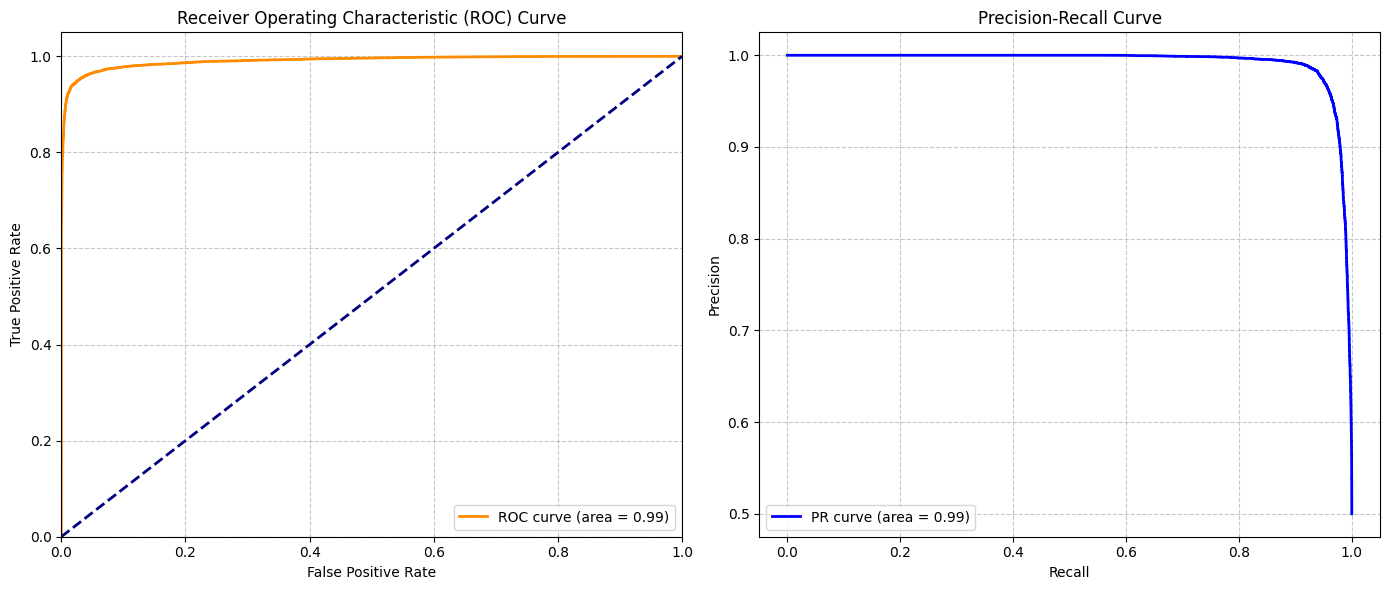

In [ ]:
# =====================================================
# 21. Generar Gráficas de Métricas
# =====================================================
plt.figure(figsize=(14, 6))

# --- Grafico 1: Curva de ROC  ---
plt.subplot(1, 2, 1)

fpr, tpr, thresholds_roc = roc_curve(test_true, test_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# --- Grafico 2: Curva de Precision-Recall  ---
plt.subplot(1, 2, 2)

precision, recall, thresholds_pr = precision_recall_curve(test_true, test_probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

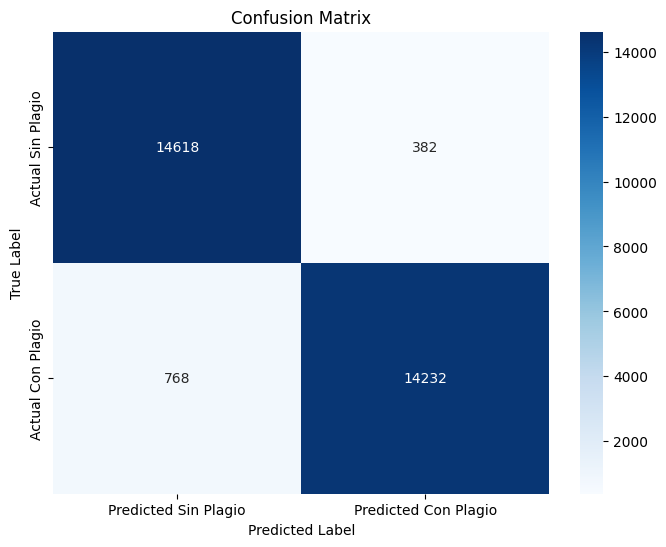

In [ ]:
# --- Grafico 3: Matriz de Confusión  ---
cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Sin Plagio', 'Predicted Con Plagio'],
            yticklabels=['Actual Sin Plagio', 'Actual Con Plagio'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()